In [1]:
# ==========================================
# STEP 1: Environment Setup and Dependencies
# ==========================================

# Install required python packages for GNN, graph analysis, and metrics
!pip install torch-geometric networkx python-Levenshtein jellyfish pandas scikit-learn matplotlib seaborn tqdm -q

import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data
from torch_geometric.utils import add_self_loops
import networkx as nx
import pandas as pd
import numpy as np
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import Levenshtein
import jellyfish
from datetime import datetime
import time
from collections import deque
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix
)

# Configure device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Using device: {device}")

# Define a robust HTTP session with automatic retry strategy for API stability
def get_robust_session():
    session = requests.Session()
    retry_strategy = Retry(total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("https://", adapter)
    return session

api_session = get_robust_session()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.6/157.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.4 MB/s eta 0:00:00:00:01
[*] Using device: cuda


In [2]:
# ==========================================
# STEP 2: Dataset Loading (npm AND PyPI)
# ==========================================

print("[*] Fetching popular npm packages from scale dataset...")
npm_rank_url = "https://github.com/tristan-f-r/npm-rank/releases/download/latest/raw.json"
npm_rank_resp = requests.get(npm_rank_url, timeout=60)
top_npm_packages = [item["name"] for item in npm_rank_resp.json()]

#print("[*] Fetching npm malicious package dataset...")
npm_malicious_url = "https://raw.githubusercontent.com/DataDog/malicious-software-packages-dataset/main/samples/npm/manifest.json"
npm_malicious_raw = requests.get(npm_malicious_url, timeout=30).json()

#print("[*] Fetching PyPI malicious package dataset...")
pypi_malicious_url = "https://raw.githubusercontent.com/DataDog/malicious-software-packages-dataset/main/samples/pypi/manifest.json"
pypi_malicious_raw = requests.get(pypi_malicious_url, timeout=30).json()

# A reasonably broad, stable PyPI popularity reference list (PyPI has no single
# canonical "npm-rank"-style ranked JSON dump, so we use a curated top-package
# list spanning common categories — this is the PyPI equivalent of seed_list).
pypi_rank_url = "https://raw.githubusercontent.com/hugovk/top-pypi-packages/main/top-pypi-packages.min.json"
pypi_rank_resp = requests.get(pypi_rank_url, timeout=30)
pypi_rank_data = pypi_rank_resp.json()

top_pypi_packages = [row["project"] for row in pypi_rank_data["rows"]]
print(f"[*] Loaded {len(top_pypi_packages)} PyPI packages ranked by real download count")
print(f"[*] Top 10: {top_pypi_packages[:10]}")



# Helper function to identify typosquatting using Levenshtein distance
def is_typosquat_like(name, targets, max_dist=2, min_len=4):
    if len(name) < min_len:
        return False, None, None
    best_target, best_dist = None, 999
    for t in targets:
        if name == t:
            continue
        d = Levenshtein.distance(name, t)
        if d < best_dist and abs(len(name) - len(t)) <= 2:
            best_dist, best_target = d, t
    if best_dist <= max_dist:
        return True, best_target, best_dist
    return False, None, None

# ---- npm typosquat filtering ----
npm_target_pool = top_npm_packages[:3000]
npm_typosquats = []
for name in npm_malicious_raw.keys():
    ok, target, dist = is_typosquat_like(name, npm_target_pool)
    if ok:
        npm_typosquats.append((name, target, dist))

npm_seed_list = top_npm_packages[:1000]
npm_known_malicious = [name for name, target, dist in npm_typosquats]

# ---- PyPI typosquat filtering ----
pypi_typosquats = []
for name in pypi_malicious_raw.keys():
    ok, target, dist = is_typosquat_like(name, top_pypi_packages)
    if ok:
        pypi_typosquats.append((name, target, dist))

pypi_seed_list = top_pypi_packages
pypi_known_malicious = [name for name, target, dist in pypi_typosquats]

print(f"[*] npm  -> Seed Pool: {len(npm_seed_list)}, Identified Typosquats: {len(npm_known_malicious)}")
print(f"[*] PyPI -> Seed Pool: {len(pypi_seed_list)}, Identified Typosquats: {len(pypi_known_malicious)}")

[*] Fetching popular npm packages from scale dataset...
[*] Loaded 15000 PyPI packages ranked by real download count
[*] Top 10: ['boto3', 'packaging', 'typing-extensions', 'certifi', 'idna', 'urllib3', 'requests', 'charset-normalizer', 'setuptools', 'cryptography']
[*] npm  -> Seed Pool: 1000, Identified Typosquats: 360
[*] PyPI -> Seed Pool: 15000, Identified Typosquats: 284


In [3]:
# ==========================================
# STEP 3: Generalized Registry Fetchers + Graph Construction
# ==========================================

def fetch_npm_data(package_name):
    url = f"https://registry.npmjs.org/{package_name}"
    try:
        response = api_session.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            latest_version = data.get("dist-tags", {}).get("latest")
            if not latest_version:
                latest_version = list(data.get("versions", {}).keys())[-1] if data.get("versions") else None
            if not latest_version:
                return None
            v_data = data.get("versions", {}).get(latest_version, {})
            created_str = data.get("time", {}).get("created", "")
            age_days = 0
            if created_str:
                try:
                    created_date = datetime.strptime(created_str[:10], "%Y-%m-%d")
                    age_days = (datetime.now() - created_date).days
                except Exception:
                    pass
            return {
                "name": data.get("name"),
                "maintainers": len(data.get("maintainers", [])),
                "dependencies": list(v_data.get("dependencies", {}).keys()),
                "age_days": age_days,
            }
        elif response.status_code == 404:
            return "NOT_FOUND"
    except Exception:
        pass
    return None


def fetch_pypi_data(package_name):
    """
    PyPI's JSON API doesn't expose a maintainer-count field the way npm does,
    so we approximate maintainers as 1 if an author/maintainer email is present
    (documented simplification — flag this in your Methodology/Limitations
    section rather than presenting it as equivalent to the npm field).
    """
    url = f"https://pypi.org/pypi/{package_name}/json"
    try:
        response = api_session.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            info = data.get("info", {})

            requires_dist = info.get("requires_dist") or []
            deps = []
            for req in requires_dist:
                dep_name = req.split()[0].split("[")[0].split(">")[0].split("=")[0].split("<")[0].strip()
                if dep_name:
                    deps.append(dep_name)

            releases = data.get("releases", {})
            upload_times = [
                r.get("upload_time") for versions in releases.values() for r in versions if r.get("upload_time")
            ]
            age_days = 0
            if upload_times:
                try:
                    earliest = min(upload_times)
                    created_date = datetime.strptime(earliest[:10], "%Y-%m-%d")
                    age_days = (datetime.now() - created_date).days
                except Exception:
                    pass

            maintainers = 1 if (info.get("author_email") or info.get("maintainer_email")) else 0

            return {
                "name": info.get("name", package_name),
                "maintainers": maintainers,
                "dependencies": deps,
                "age_days": age_days,
            }
        elif response.status_code == 404:
            return "NOT_FOUND"
    except Exception:
        pass
    return None


FETCHERS = {"npm": fetch_npm_data, "pypi": fetch_pypi_data}


def build_dependency_graph(seed_packages, malicious_packages, ecosystem="npm", max_hops=1):
    fetch_fn = FETCHERS[ecosystem]
    print(f"[*] Building {ecosystem} Graph (Max Hops: {max_hops})...")
    G = nx.DiGraph()
    visited = set()
    initial_nodes = list(seed_packages) + list(malicious_packages)
    queue = deque([(pkg, 0) for pkg in initial_nodes])
    package_metadata = {}

    pbar = tqdm(desc=f"Fetching {ecosystem} nodes")
    while queue:
        current_pkg, hop = queue.popleft()
        if current_pkg in visited or hop > max_hops:
            continue
        visited.add(current_pkg)
        pbar.update(1)

        pkg_data = fetch_fn(current_pkg)
        time.sleep(0.05)

        if isinstance(pkg_data, dict):
            package_metadata[current_pkg] = pkg_data
            G.add_node(current_pkg)
            for dep in pkg_data["dependencies"]:
                G.add_node(dep)
                G.add_edge(current_pkg, dep)
                if dep not in visited and hop + 1 <= max_hops:
                    queue.append((dep, hop + 1))
        elif pkg_data == "NOT_FOUND" and current_pkg in malicious_packages:
            G.add_node(current_pkg)
            package_metadata[current_pkg] = {"name": current_pkg, "maintainers": 0, "dependencies": [], "age_days": 0}

    pbar.close()
    return G, package_metadata



NPM_SEED_CAP = 300
NPM_MALICIOUS_CAP = 250
PYPI_SEED_CAP = 300       
PYPI_MALICIOUS_CAP = len(pypi_known_malicious)

npm_seed_sample = npm_seed_list[:NPM_SEED_CAP]
npm_malicious_sample = npm_known_malicious[:NPM_MALICIOUS_CAP]

pypi_seed_sample = pypi_seed_list[:PYPI_SEED_CAP]
pypi_malicious_sample = pypi_known_malicious[:PYPI_MALICIOUS_CAP]

G_npm, metadata_npm = build_dependency_graph(npm_seed_sample, npm_malicious_sample, ecosystem="npm", max_hops=1)
print(f"[*] npm Graph -> Nodes: {G_npm.number_of_nodes()}, Edges: {G_npm.number_of_edges()}")

G_pypi, metadata_pypi = build_dependency_graph(pypi_seed_sample, pypi_malicious_sample, ecosystem="pypi", max_hops=1)
print(f"[*] PyPI Graph -> Nodes: {G_pypi.number_of_nodes()}, Edges: {G_pypi.number_of_edges()}")

[*] Building npm Graph (Max Hops: 1)...


Fetching npm nodes: 934it [01:32, 10.14it/s]


[*] npm Graph -> Nodes: 1145, Edges: 1400
[*] Building pypi Graph (Max Hops: 1)...


Fetching pypi nodes: 1602it [03:36,  7.42it/s]

[*] PyPI Graph -> Nodes: 3105, Edges: 7847


In [4]:
# ==========================================
# STEP 4: Generalized Feature Extraction
# ==========================================

def extract_features(G, metadata, seed_pool):
    node_list = list(G.nodes())
    node_idx = {name: i for i, name in enumerate(node_list)}
    pagerank_scores = nx.pagerank(G, alpha=0.85)

    def get_lexical_similarity(name, popular_targets):
        targets = [t for t in popular_targets if t != name]  # exclude self-match
        if not targets:
            return 0, 99
        jw_sim = max(jellyfish.jaro_winkler_similarity(name, t) for t in targets)
        lev_dist = min(Levenshtein.distance(name, t) for t in targets)
        return jw_sim, lev_dist

    features = []
    for n in node_list:
        jw_sim, lev_dist = get_lexical_similarity(n, seed_pool)
        age = metadata.get(n, {}).get("age_days", 0)
        maintainers = metadata.get(n, {}).get("maintainers", 0)
        in_deg = G.in_degree(n)
        pr_score = pagerank_scores.get(n, 0)
        features.append([jw_sim, lev_dist, age, maintainers, in_deg, pr_score])

    X = np.array(features, dtype=np.float32)
    X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0) + 1e-6)
    return node_list, node_idx, X


npm_node_list, npm_node_idx, X_npm = extract_features(G_npm, metadata_npm, npm_seed_sample)
print(f"[*] npm Feature Matrix Shape: {X_npm.shape}")

pypi_node_list, pypi_node_idx, X_pypi = extract_features(G_pypi, metadata_pypi, pypi_seed_sample)
print(f"[*] PyPI Feature Matrix Shape: {X_pypi.shape}")

[*] npm Feature Matrix Shape: (1145, 6)
[*] PyPI Feature Matrix Shape: (3105, 6)


In [12]:
# ==========================================
# STEP 5: Model Definitions (unchanged architecture)
# ==========================================

class TyposquatGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = self.bn1(h)
        h = F.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        return self.conv2(h, edge_index)


class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=3.0, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alpha_factor = torch.where(targets == 1, self.alpha, 1.0)
        return (alpha_factor * (1 - pt) ** self.gamma * ce_loss).mean()

In [6]:
# ==========================================
# STEP 6: Single-Experiment Runner
# ==========================================

def run_single_experiment(G, metadata, node_list, node_idx, X, malicious_sample,
                           seed=42, hidden_channels=64, out_channels=32, epochs=200,
                           alpha=3.0, gamma=2.0, lr=0.01, weight_decay=1e-3):

    edge_index = torch.tensor(
        [[node_idx[u], node_idx[v]] for u, v in G.edges()], dtype=torch.long
    ).t().contiguous() if G.number_of_edges() > 0 else torch.empty((2, 0), dtype=torch.long)
    edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_list))

    x = torch.tensor(X, dtype=torch.float)
    y = torch.tensor([1 if n in malicious_sample else 0 for n in node_list], dtype=torch.long)
    data = Data(x=x, edge_index=edge_index, y=y).to(device)

    all_idx = np.arange(len(node_list))
    labels_np = data.y.cpu().numpy()

    if len(all_idx) < 20 or min(np.bincount(labels_np)) < 4:
        return None  # not enough data for a reliable 3-way split at this seed

    # first carve out test (20%), then split remaining into train/val (75/25 of the rest -> 60/20/20 overall)
    train_val_idx, test_idx_np = train_test_split(
        all_idx, test_size=0.2, stratify=labels_np, random_state=seed
    )
    train_idx_np, val_idx_np = train_test_split(
        train_val_idx, test_size=0.25, stratify=labels_np[train_val_idx], random_state=seed
    )

    train_idx = torch.tensor(train_idx_np, dtype=torch.long).to(device)
    val_idx = torch.tensor(val_idx_np, dtype=torch.long).to(device)
    test_idx = torch.tensor(test_idx_np, dtype=torch.long).to(device)

    torch.manual_seed(seed)
    model = TyposquatGNN(in_channels=X.shape[1], hidden_channels=hidden_channels, out_channels=out_channels).to(device)
    classifier = torch.nn.Linear(out_channels, 2).to(device)
    criterion = FocalLoss(alpha=alpha, gamma=gamma)
    optimizer = torch.optim.Adam(list(model.parameters()) + list(classifier.parameters()), lr=lr, weight_decay=weight_decay)

    best_val_f1 = -1
    best_state = None
    for epoch in range(1, epochs + 1):
        model.train(); classifier.train()
        optimizer.zero_grad()
        emb = model(data.x, data.edge_index)
        logits = classifier(emb[train_idx])
        loss = criterion(logits, data.y[train_idx])
        loss.backward()
        optimizer.step()

      
        if epoch % 10 == 0 or epoch == epochs:
            model.eval(); classifier.eval()
            with torch.no_grad():
                val_emb = model(data.x, data.edge_index)
                val_logits = classifier(val_emb[val_idx])
                val_preds = val_logits.argmax(dim=1).cpu().numpy()
                val_true = data.y[val_idx].cpu().numpy()
                val_f1 = f1_score(val_true, val_preds, zero_division=0)
                if val_f1 >= best_val_f1:
                    best_val_f1 = val_f1
                    best_state = (
                        {k: v.clone() for k, v in model.state_dict().items()},
                        {k: v.clone() for k, v in classifier.state_dict().items()},
                    )

    if best_state is not None:
        model.load_state_dict(best_state[0])
        classifier.load_state_dict(best_state[1])

    
    model.eval(); classifier.eval()
    with torch.no_grad():
        all_embs = model(data.x, data.edge_index)
        logits = classifier(all_embs[test_idx])
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        true_labels = data.y[test_idx].cpu().numpy()

    gnn_metrics = {
        "precision": precision_score(true_labels, preds, zero_division=0),
        "recall": recall_score(true_labels, preds, zero_division=0),
        "f1": f1_score(true_labels, preds, zero_division=0),
        "pr_auc": average_precision_score(true_labels, probs) if len(set(true_labels)) > 1 else np.nan,
        "roc_auc": roc_auc_score(true_labels, probs) if len(set(true_labels)) > 1 else np.nan,
    }

   
    lexical_only_X = X[:, :2]  # columns 0,1 = jaro-winkler similarity, levenshtein distance
    baseline = LogisticRegression(class_weight="balanced", max_iter=1000)
    baseline.fit(lexical_only_X[train_idx_np], labels_np[train_idx_np])
    baseline_preds = baseline.predict(lexical_only_X[test_idx_np])
    baseline_probs = baseline.predict_proba(lexical_only_X[test_idx_np])[:, 1]

    baseline_metrics = {
        "precision": precision_score(true_labels, baseline_preds, zero_division=0),
        "recall": recall_score(true_labels, baseline_preds, zero_division=0),
        "f1": f1_score(true_labels, baseline_preds, zero_division=0),
        "pr_auc": average_precision_score(true_labels, baseline_probs) if len(set(true_labels)) > 1 else np.nan,
        "roc_auc": roc_auc_score(true_labels, baseline_probs) if len(set(true_labels)) > 1 else np.nan,
    }

    # Semantic-gap fusion feature (for plotting), computed for every node
    popular_idx = [node_idx[n] for n in node_list if n in node_idx and n not in malicious_sample][:len(node_list)]
    # use the actual seed pool present in the graph as the "popular" reference cloud
    seed_in_graph_idx = [node_idx[n] for n in node_list if n in node_idx][: max(1, len(node_list)//5)]
    with torch.no_grad():
        popular_embs = all_embs[seed_in_graph_idx]

        def get_graph_distance(node_id):
            emb = all_embs[node_id].unsqueeze(0)
            return torch.cdist(emb, popular_embs).min().item()

        graph_dist = np.array([get_graph_distance(i) for i in range(len(node_list))]).reshape(-1, 1)
    graph_dist = graph_dist / (graph_dist.max() + 1e-6)
    fusion_X = np.hstack([X[:, 0].reshape(-1, 1), graph_dist])

    return {
        "seed": seed,
        "n_test": len(test_idx_np),
        "n_test_positive": int(true_labels.sum()),
        "gnn": gnn_metrics,
        "baseline": baseline_metrics,
        "test_idx": test_idx_np,
        "true_labels": true_labels,
        "fusion_X": fusion_X,
    }

In [7]:
# ==========================================
# STEP 7: Multi-Seed Robustness Evaluation
# ==========================================

def multi_seed_evaluation(G, metadata, node_list, node_idx, X, malicious_sample,
                           seeds=(42, 7, 123, 2024, 99), ecosystem_name="npm"):
    rows = []
    last_result = None
    for seed in seeds:
        result = run_single_experiment(G, metadata, node_list, node_idx, X, malicious_sample, seed=seed)
        if result is None:
            print(f"[!] Seed {seed}: skipped (not enough labeled data for a reliable split)")
            continue
        last_result = result
        rows.append({
            "seed": seed,
            "n_test": result["n_test"],
            "n_test_positive": result["n_test_positive"],
            "gnn_f1": result["gnn"]["f1"],
            "gnn_precision": result["gnn"]["precision"],
            "gnn_recall": result["gnn"]["recall"],
            "gnn_pr_auc": result["gnn"]["pr_auc"],
            "gnn_roc_auc": result["gnn"]["roc_auc"],
            "baseline_f1": result["baseline"]["f1"],
            "baseline_precision": result["baseline"]["precision"],
            "baseline_recall": result["baseline"]["recall"],
            "baseline_pr_auc": result["baseline"]["pr_auc"],
            "baseline_roc_auc": result["baseline"]["roc_auc"],
        })

    df = pd.DataFrame(rows)
    if df.empty:
        print(f"[!] {ecosystem_name}: no valid seeds — dataset too small, increase seed/malicious sample size.")
        return df, last_result

    summary = df[["gnn_f1", "gnn_precision", "gnn_recall", "gnn_pr_auc", "gnn_roc_auc",
                   "baseline_f1", "baseline_precision", "baseline_recall", "baseline_pr_auc", "baseline_roc_auc"]].agg(["mean", "std"])

    print(f"\n{'='*70}\n[{ecosystem_name.upper()}] Multi-seed results (n={len(df)} seeds)\n{'='*70}")
    print(df.to_string(index=False))
    print(f"\n[{ecosystem_name.upper()}] Summary (mean +/- std):")
    for metric in ["f1", "precision", "recall", "pr_auc", "roc_auc"]:
        g_mean, g_std = summary.loc["mean", f"gnn_{metric}"], summary.loc["std", f"gnn_{metric}"]
        b_mean, b_std = summary.loc["mean", f"baseline_{metric}"], summary.loc["std", f"baseline_{metric}"]
        print(f"  {metric:10s} | GNN: {g_mean:.4f} +/- {g_std:.4f}   |  Baseline: {b_mean:.4f} +/- {b_std:.4f}")

    return df, last_result

In [8]:
# ==========================================
# STEP 8: Run for npm
# ==========================================
npm_results_df, npm_last_result = multi_seed_evaluation(
    G_npm, metadata_npm, npm_node_list, npm_node_idx, X_npm, npm_malicious_sample,
    seeds=(42, 7, 123, 2024, 99), ecosystem_name="npm"
)


[NPM] Multi-seed results (n=5 seeds)
 seed  n_test  n_test_positive   gnn_f1  gnn_precision  gnn_recall  gnn_pr_auc  gnn_roc_auc  baseline_f1  baseline_precision  baseline_recall  baseline_pr_auc  baseline_roc_auc
   42     229               46 0.954545       1.000000    0.913043    0.944229     0.959135     0.473373            0.325203         0.869565         0.502997          0.820029
    7     229               46 0.946237       0.936170    0.956522    0.981624     0.985745     0.485207            0.333333         0.891304         0.473986          0.817831
  123     229               46 0.956522       0.956522    0.956522    0.979924     0.988239     0.477987            0.336283         0.826087         0.530537          0.820682
 2024     229               46 0.967033       0.977778    0.956522    0.986108     0.991684     0.506173            0.353448         0.891304         0.634139          0.878297
   99     229               46 0.956522       0.956522    0.956522    0.98893

In [9]:
# ==========================================
# STEP 9: Run for PyPI
# ==========================================
pypi_results_df, pypi_last_result = multi_seed_evaluation(
    G_pypi, metadata_pypi, pypi_node_list, pypi_node_idx, X_pypi, pypi_malicious_sample,
    seeds=(42, 7, 123, 2024, 99), ecosystem_name="pypi"
)


[PYPI] Multi-seed results (n=5 seeds)
 seed  n_test  n_test_positive   gnn_f1  gnn_precision  gnn_recall  gnn_pr_auc  gnn_roc_auc  baseline_f1  baseline_precision  baseline_recall  baseline_pr_auc  baseline_roc_auc
   42     621               57 0.974359           0.95    1.000000    1.000000     1.000000     0.280255            0.171206         0.771930         0.196112          0.729999
    7     621               57 1.000000           1.00    1.000000    1.000000     1.000000     0.264151            0.160920         0.736842         0.230564          0.724664
  123     621               57 0.982143           1.00    0.964912    0.993853     0.999253     0.303630            0.186992         0.807018         0.312725          0.794762
 2024     621               57 0.982143           1.00    0.964912    0.998277     0.999813     0.290909            0.175824         0.842105         0.235749          0.758834
   99     621               57 1.000000           1.00    1.000000    1.0000


[*] Generating visualization for npm...


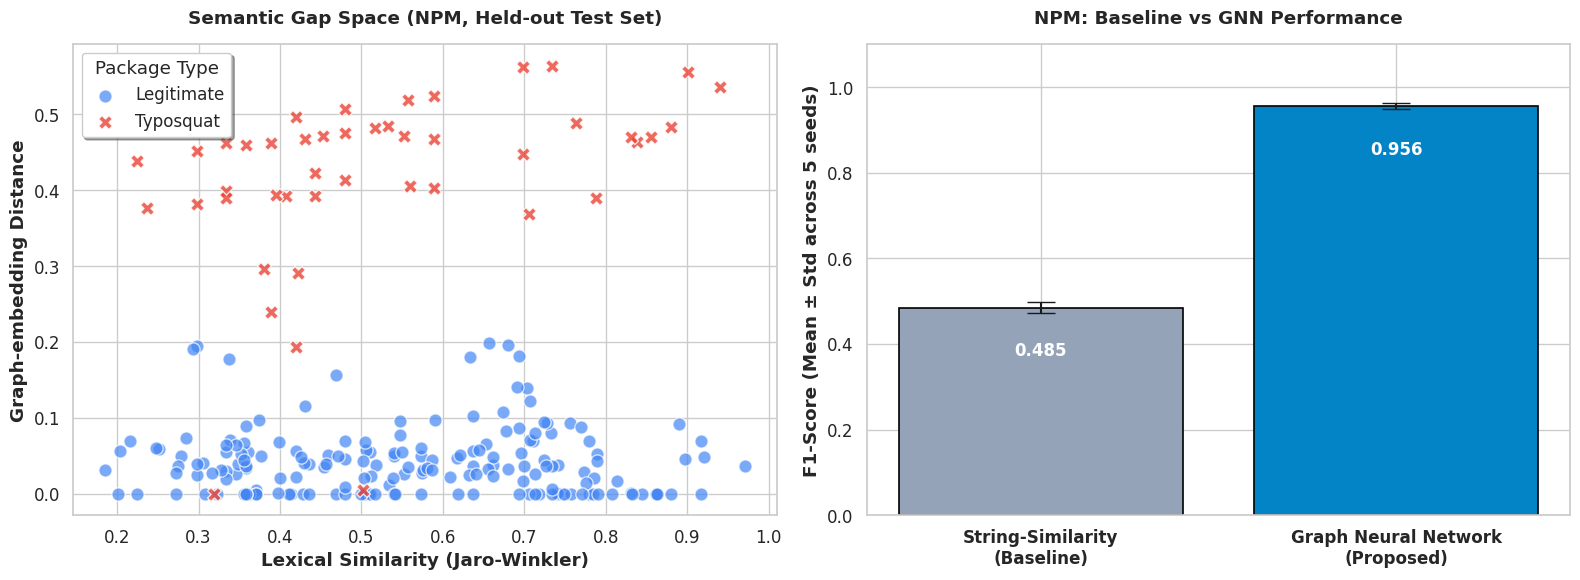

[*] Saved high-resolution plot to: /kaggle/working/npm_evaluation_plots.png

[*] Generating visualization for PyPI...


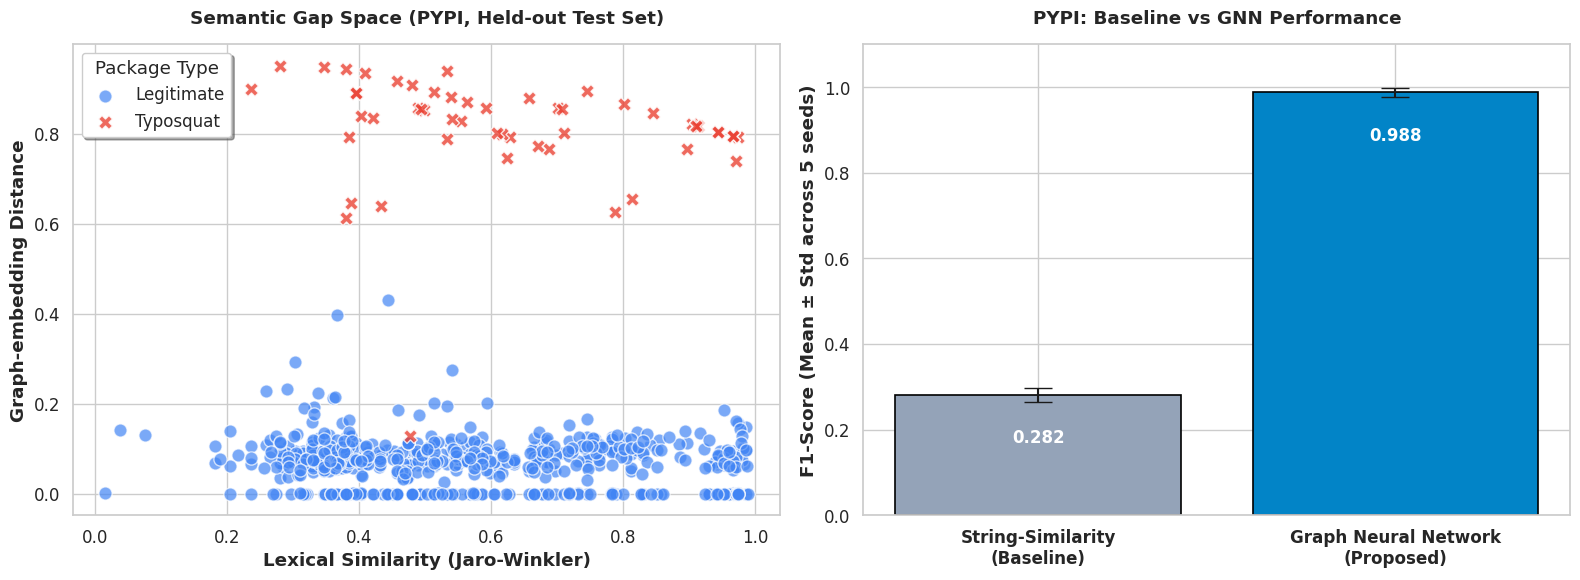

[*] Saved high-resolution plot to: /kaggle/working/PyPI_evaluation_plots.png


In [13]:
# ==========================================
# STEP 10:  Visualization
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_evaluation_results(results_df, last_result, ecosystem_name="npm"):
    # Set seaborn theme for professional aesthetics
    sns.set_theme(style="whitegrid", font_scale=1.1)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # ---------------------------------------------------------
    # Plot 1: Semantic Gap Space (Scatter Plot)
    # ---------------------------------------------------------
    if last_result is not None:
        test_idx_arr = last_result["test_idx"]
        fusion_X = last_result["fusion_X"]
        true_labels = last_result["true_labels"]
        
        # Scatter for Legitimate Packages (Label 0)
        axes[0].scatter(fusion_X[test_idx_arr][true_labels == 0, 0], 
                        fusion_X[test_idx_arr][true_labels == 0, 1],
                        color='#4285F4', label='Legitimate', alpha=0.7, s=90, edgecolor='w')
        
        # Scatter for Typosquat/Malicious Packages (Label 1)
        axes[0].scatter(fusion_X[test_idx_arr][true_labels == 1, 0], 
                        fusion_X[test_idx_arr][true_labels == 1, 1],
                        color='#EA4335', label='Typosquat', alpha=0.8, s=100, edgecolor='w', marker='X')
        
        axes[0].set_xlabel("Lexical Similarity (Jaro-Winkler)", fontweight='bold')
        axes[0].set_ylabel("Graph-embedding Distance", fontweight='bold')
        axes[0].set_title(f"Semantic Gap Space ({ecosystem_name.upper()}, Held-out Test Set)", fontweight='bold', pad=15)
        axes[0].legend(title="Package Type", loc="upper left", frameon=True, shadow=True)
    
    # ---------------------------------------------------------
    # Plot 2: GNN vs Baseline Performance (Bar Chart)
    # ---------------------------------------------------------
    if not results_df.empty:
        x_pos = np.arange(2)
        gnn_mean = results_df["gnn_f1"].mean()
        gnn_std = results_df["gnn_f1"].std()
        base_mean = results_df["baseline_f1"].mean()
        base_std = results_df["baseline_f1"].std()
        
        bars = axes[1].bar(x_pos, [base_mean, gnn_mean], yerr=[base_std, gnn_std], 
                           capsize=10, color=["#94A3B8", "#0284C7"], edgecolor='black', linewidth=1.2)
        
        axes[1].set_xticks(x_pos)
        axes[1].set_xticklabels(["String-Similarity\n(Baseline)", "Graph Neural Network\n(Proposed)"], fontweight='bold')
        axes[1].set_ylabel("F1-Score (Mean ± Std across 5 seeds)", fontweight='bold')
        axes[1].set_title(f"{ecosystem_name.upper()}: Baseline vs GNN Performance", fontweight='bold', pad=15)
        axes[1].set_ylim(0, 1.1)
        
        # Annotate bar values inside the bars
        for bar in bars:
            yval = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2, yval - 0.08, f"{yval:.3f}", 
                         ha='center', va='top', color='white', fontweight='bold', fontsize=12)

    plt.tight_layout()
    # Save the plot with High Resolution (300 DPI)
    save_path = f"/kaggle/working/{ecosystem_name}_evaluation_plots.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[*] Saved high-resolution plot to: {save_path}")

# ==========================================
# Generate and display plots for both ecosystems
# ==========================================
print("\n[*] Generating visualization for npm...")
plot_evaluation_results(npm_results_df, npm_last_result, ecosystem_name="npm")

print("\n[*] Generating visualization for PyPI...")
plot_evaluation_results(pypi_results_df, pypi_last_result, ecosystem_name="PyPI")

In [11]:
# ==========================================
# STEP 11: Save Results
# ==========================================
npm_results_df.to_csv("/kaggle/working/npm_multiseed_results.csv", index=False)
pypi_results_df.to_csv("/kaggle/working/pypi_multiseed_results.csv", index=False)
print("[*] Pipeline complete. Multi-seed results + comparison plots saved to /kaggle/working/")

[*] Pipeline complete. Multi-seed results + comparison plots saved to /kaggle/working/


In [15]:
# ==========================================
# STEP 12: Create ZIP for PC Download
# ==========================================
import networkx as nx
import shutil
import os
from IPython.display import FileLink, display

print("[*] Saving NetworkX Graphs to disk...")

nx.write_graphml(G_npm, "/kaggle/working/npm_dependency_graph.graphml")
nx.write_graphml(G_pypi, "/kaggle/working/pypi_dependency_graph.graphml")

print("[*] Compressing files into a ZIP archive safely...")
archive_name = "Typosquatting_Project_Files"
temp_zip_path = f"/tmp/{archive_name}"


shutil.make_archive(temp_zip_path, 'zip', '/kaggle/working/')


final_zip_path = f"/kaggle/working/{archive_name}.zip"
shutil.move(f"{temp_zip_path}.zip", final_zip_path)

if os.path.exists(final_zip_path):
    print(f"\n[✓] ZIP file created successfully: {archive_name}.zip")
    print("[*] Click the link below to download it to your PC:")
    
    display(FileLink(f"{archive_name}.zip"))
else:
    print("[!] Failed to create ZIP file.")

[*] Saving NetworkX Graphs to disk...
[*] Compressing files into a ZIP archive safely...

[✓] ZIP file created successfully: Typosquatting_Project_Files.zip
[*] Click the link below to download it to your PC:


/kaggle/working/Typosquatting_Project_Files.zip